In [73]:
import numpy as np
import matplotlib.pyplot as plt
import math as m
import pandas as pd
import seaborn as sb

# HW 9a

## 6.2

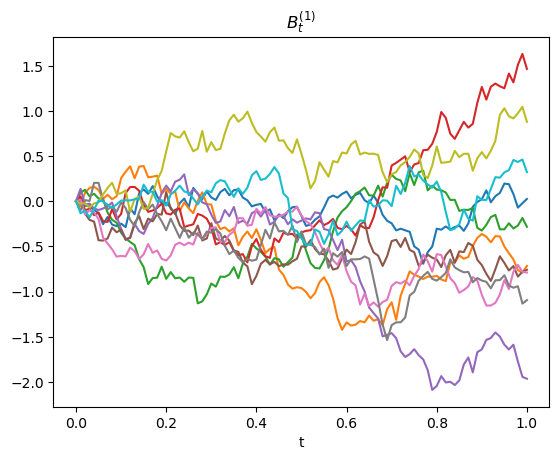

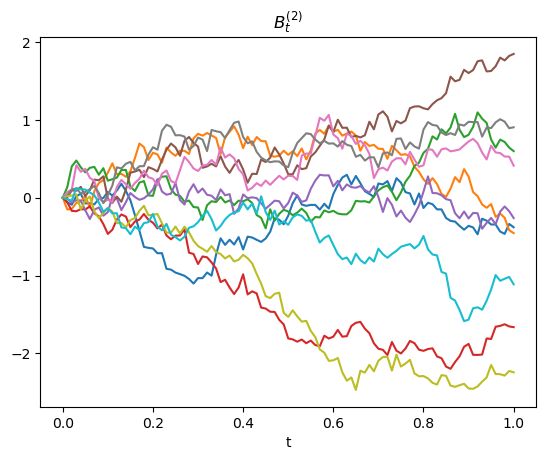

In [74]:
diff = 0.01
x = np.arange(0,1+diff, diff)

samples1 = np.random.normal(loc = 0, scale = m.sqrt(diff), size=(10, len(x)-1))
samples2 = np.random.normal(loc = 0, scale = m.sqrt(diff), size=(10, len(x)-1))

samples1 = np.append(np.zeros(shape=(10,1)), samples1, axis=1)
samples2 = np.append(np.zeros(shape=(10,1)), samples2, axis=1)

BM1 = np.cumsum(samples1, axis=1)
BM2 = np.cumsum(samples2, axis=1)

plt.plot(x,BM1.T)
plt.title(r"$B_{t}^{(1)}$")
plt.xlabel("t")
plt.show()

plt.plot(x,BM2.T)
plt.title(r"$B_{t}^{(2)}$")
plt.xlabel("t")
plt.show()

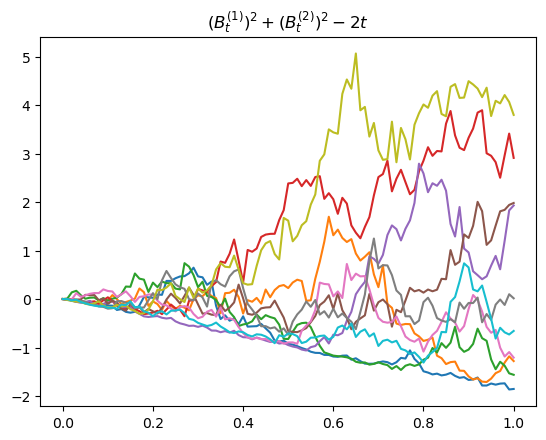

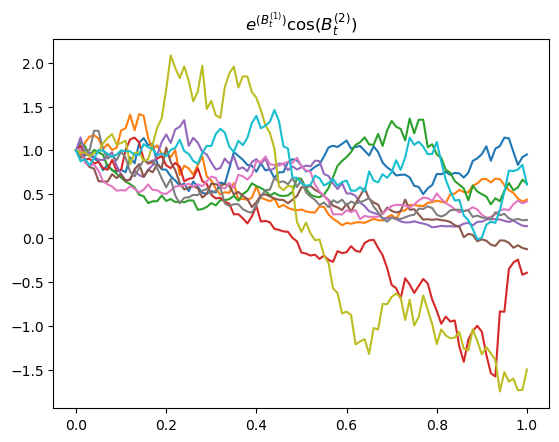

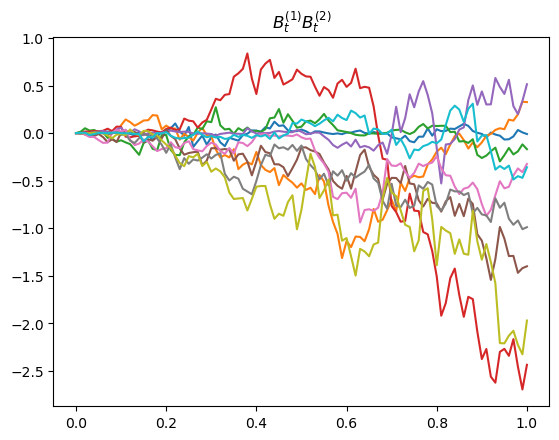

In [75]:
Xt = (BM1)**2 + (BM2)**2 - (2*x)
# Xt2 = (BM1)**2 + (BM2)**2 - x
Yt = np.exp(BM1) * np.cos(BM2)
Zt = BM1 * BM2

plt.plot(x,Xt.T)
plt.title(r"$(B_{t}^{(1)})^2 + (B_{t}^{(2)})^2 - 2t$")
plt.show()

plt.plot(x,Yt.T)
plt.title(r"$e^{(B_{t}^{(1)})}\cos(B_{t}^{(2)})$")
plt.show()

plt.plot(x,Zt.T)
plt.title(r"$B_{t}^{(1)}B_{t}^{(2)}$")
plt.show()


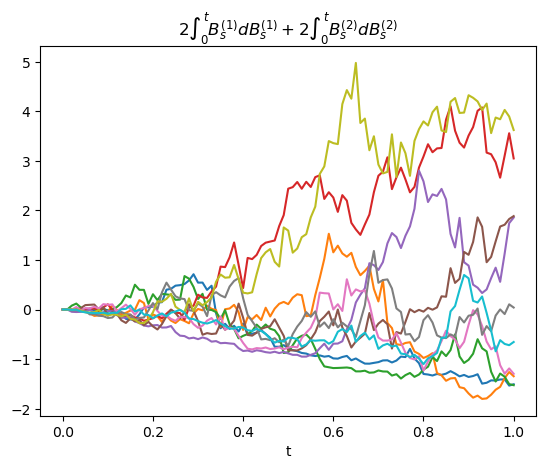

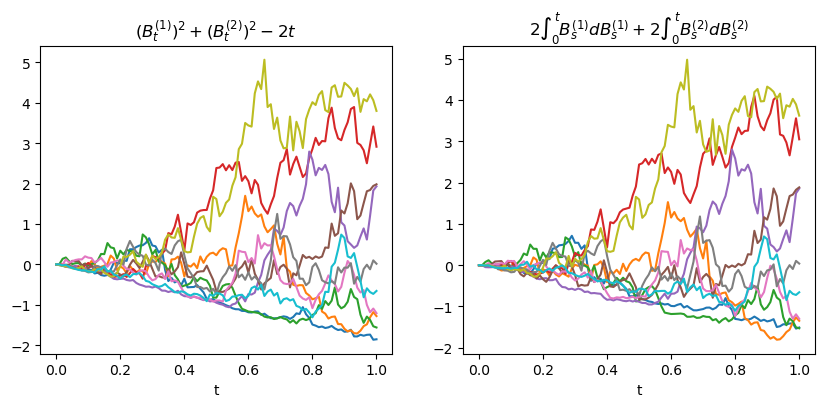

In [76]:
f1 = np.cumsum(np.insert(2*BM1[:,:-1] * np.diff(BM1),0,0,axis=1),axis=1)
f2 = np.cumsum(np.insert(2*BM2[:,:-1] * np.diff(BM2),0,0,axis=1),axis=1)
X_t = f1 + f2

plt.plot(x,X_t.T)
plt.title(r"$2\int_{0}^{t}B_{s}^{(1)}dB_{s}^{(1)} + 2\int_{0}^{t}B_{s}^{(2)}dB_{s}^{(2)}$")
plt.xlabel("t")
plt.show()

fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax1.plot(x,Xt.T)
ax1.set_title(r"$(B_{t}^{(1)})^2 + (B_{t}^{(2)})^2 - 2t$")
ax1.set_xlabel("t")
ax2.plot(x,X_t.T)
ax2.set_title(r"$2\int_{0}^{t}B_{s}^{(1)}dB_{s}^{(1)} + 2\int_{0}^{t}B_{s}^{(2)}dB_{s}^{(2)}$")
ax2.set_xlabel("t")
plt.show()

# fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
# ax1.plot(x,Xt2.T)
# ax2.plot(x,X_t.T)
# plt.show()




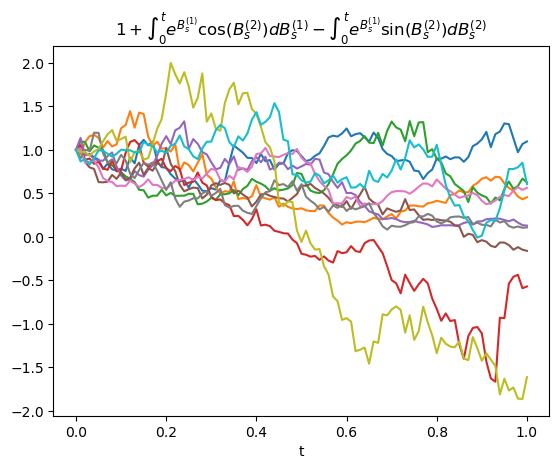

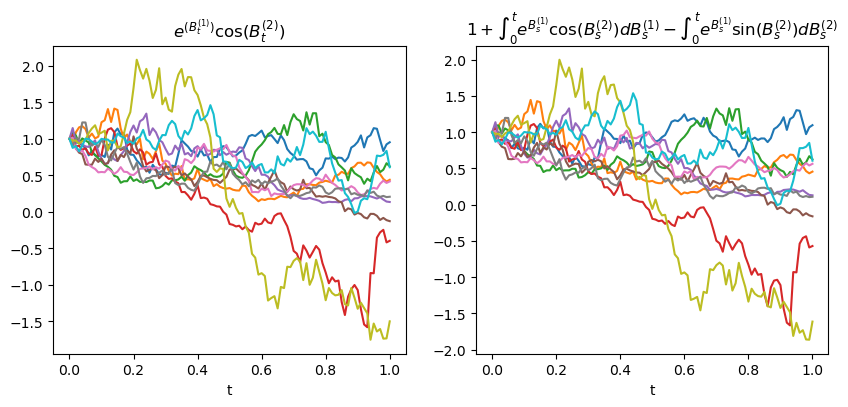

In [77]:
ecos = np.exp(BM1) * np.cos(BM2)
f3 = np.cumsum(np.insert(ecos[:,:-1] * np.diff(BM1), 0, 0, axis=1), axis=1)
esin = np.exp(BM1) * np.sin(BM2)
f4 = np.cumsum(np.insert(esin[:,:-1] * np.diff(BM2), 0, 0, axis=1), axis=1)

Y_t = 1 + f3 - f4

plt.plot(x,Y_t.T)
plt.title(r"$ 1 + \int_{0}^{t}e^{B_{s}^{(1)}}\cos({B_{s}^{(2)}})dB_{s}^{(1)} - \int_{0}^{t}e^{B_{s}^{(1)}}\sin({B_{s}^{(2)}})dB_{s}^{(2)}$")
plt.xlabel("t")
plt.show()

fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax1.set_title(r"$e^{(B_{t}^{(1)})}\cos(B_{t}^{(2)})$")
ax1.set_xlabel("t")
ax1.plot(x,Yt.T)

ax2.plot(x,Y_t.T)
ax2.set_title(r"$ 1 + \int_{0}^{t}e^{B_{s}^{(1)}}\cos({B_{s}^{(2)}})dB_{s}^{(1)} - \int_{0}^{t}e^{B_{s}^{(1)}}\sin({B_{s}^{(2)}})dB_{s}^{(2)}$")
ax2.set_xlabel("t")
plt.show()

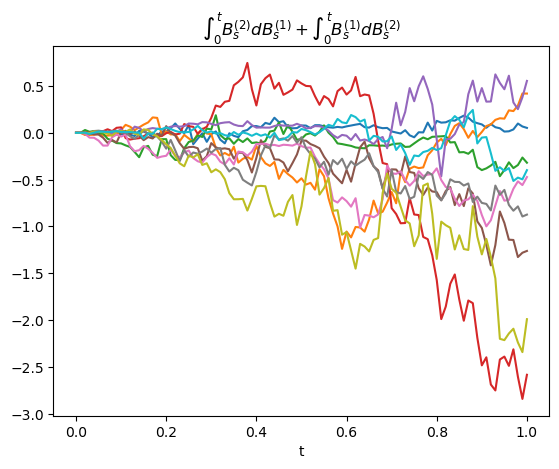

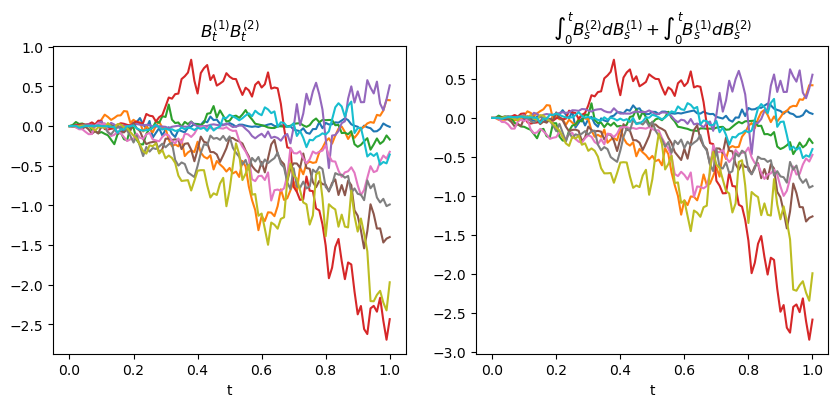

In [78]:
f5 = np.cumsum(np.insert(BM2[:,:-1] * np.diff(BM1), 0, 0, axis=1), axis=1)
f6 = np.cumsum(np.insert(BM1[:,:-1] * np.diff(BM2), 0, 0, axis=1), axis=1)

Z_t = f5 + f6

plt.plot(x,Z_t.T)
plt.title(r"$\int_{0}^{t}B_{s}^{(2)}dB_{s}^{(1)} + \int_{0}^{t}B_{s}^{(1)}dB_{s}^{(2)}$")
plt.xlabel("t")
plt.show()

fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax1.plot(x,Zt.T)
ax1.set_title(r"$B_{t}^{(1)}B_{t}^{(2)}$")
ax1.set_xlabel("t")
ax2.plot(x,Z_t.T)
ax2.set_title(r"$\int_{0}^{t}B_{s}^{(2)}dB_{s}^{(1)} + \int_{0}^{t}B_{s}^{(1)}dB_{s}^{(2)}$")
ax2.set_xlabel("t")
plt.show()

## 6.3

In [79]:
def h(y):
    if y >= 0:
        return 1
    return -1

def circle(B_t):
    return B_t[0]**2 + B_t[1]**2

### a

In [80]:
results = []
for _ in range(1000):
    BM = [0,1/2]
    while circle(BM) < 1:
        BM = [BM[0] + np.random.normal(loc = 0, scale=m.sqrt(diff)),BM[1] + np.random.normal(loc = 0, scale=m.sqrt(0.01))]
    results.append(h(BM[1]))

print("h(0,1/2) = ", np.mean(results))



h(0,1/2) =  0.56


### b

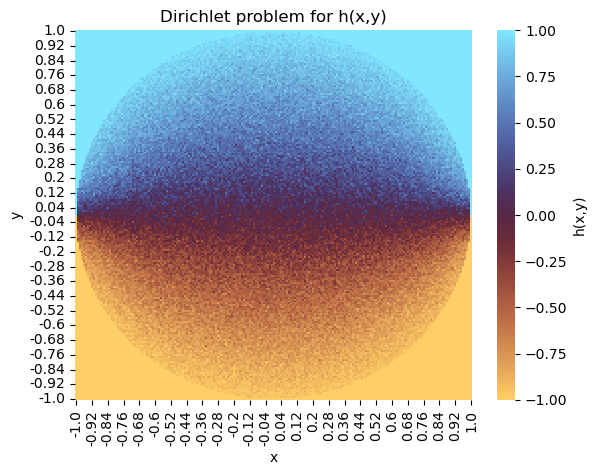

0


In [81]:
final = []
time = np.arange(0,6 + diff,diff)
counts = {}
# f

bottom = []
side = []

for x in np.arange(-1,1+diff,diff):
    for y in np.arange(-1,1+diff,diff):
        bottom.append(round(x, 2))
        side.append(round(y, 2))
        if (x**2 + y**2) >= 1:
            counts[(x,y)] = 100
            final.append(h(y))
        else: 
            samples1 = np.random.normal(loc = 0, scale = m.sqrt(diff), size=(100, len(time)-1))
            samples2 = np.random.normal(loc = 0, scale = m.sqrt(diff), size=(100, len(time)-1))
            yeet1 = np.append(np.zeros(shape=(100,1)) + x , samples1, axis=1)
            yeet2 = np.append(np.zeros(shape=(100,1)) + y, samples2, axis=1)

            BM1 = np.cumsum(yeet1, axis=1)
            BM2 = np.cumsum(yeet2, axis=1)

            R_2 = BM1**2 + BM2**2

            index = np.argmax(R_2 >= 1, axis=1)

            counts[(x,y)] = np.count_nonzero(index != 0)

            postitions = BM2[np.arange(len(index)),index]

            final.append(np.mean(np.where(postitions >= 0, 1, -1)))

data = {'x' : bottom , 'y' : side, 'z' : final}
df = pd.DataFrame.from_dict(data)

df.to_csv('final.csv')

sb.heatmap(df.pivot(index='y', columns='x', values='z'), cmap='managua', cbar_kws={'label': 'h(x,y)'})
plt.gca().invert_yaxis()
plt.title("Dirichlet problem for h(x,y)")
plt.show()

count = 0
for key,data in counts.items():
    if data != 100:
        count += 1
        print(f"{key} has a different value: {data}")

print(count)